In [1]:
!pip install statsmodels --quiet

# 1. Data Loading
- load facts, merge dim_temps+dim_zone, remove phantom zones, print shapes


In [2]:
import os
os.chdir(r'C:\Users\sbiss\OneDrive - ESPRIT\Desktop\actor1_ecologique')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import Lasso
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score, davies_bouldin_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import joblib
import logging
import warnings

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.ERROR)
os.makedirs('outputs', exist_ok=True)


c:\Users\sbiss\OneDrive - ESPRIT\Desktop\actor1_ecologique\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
def load_and_clean_data(fact_path="fact_impact_territorial.csv", time_dim_path="dim_temps.csv"):
    df_facts = pd.read_csv(fact_path)
    df_temps = pd.read_csv(time_dim_path)
    df = pd.merge(df_facts, df_temps, on='time_sk', how='left')
    
    cols_to_drop = ['weather_sk', 'event_sk', 'temperature', 'condition_text']
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    df.drop_duplicates(subset=['time_sk', 'zone_sk', 'mode_sk'], inplace=True)
    
    df_zone = pd.read_csv('dim_zone.csv')
    df = pd.merge(df, df_zone[['zone_sk', 'zone_nom', 'zone_code', 'ville']], on='zone_sk', how='left')
    
    valid_zones = (
        df['zone_sk'].between(1, 10) & 
        df['zone_nom'].notna() & 
        (df['zone_nom'].str.strip().str.upper() != 'UNKNOWN')
    )
    df = df[valid_zones].copy()
    
    cols_to_keep = ['fact_impact_sk', 'time_sk', 'zone_sk', 'mode_sk', 'energie_kwh', 'co2_kg', 'aqi_index', 'pm25', 'no2', 'nb_accidents', 'nb_graves', 'nb_mortels', 'usagers_vulnerables', 'volume_crimes', 'taux_criminalite', 'annee', 'mois', 'jour_semaine', 'periode', 'zone_nom', 'zone_code', 'ville', 'mode']
    actual_keep = [c for c in cols_to_keep if c in df.columns]
    df = df[actual_keep].copy()
    
    for col in ['co2_kg', 'energie_kwh', 'aqi_index', 'pm25', 'no2']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df[df['co2_kg'] > 0].copy()
    return df

try:
    df_clean = load_and_clean_data()
    print(f"Shape: {df_clean.shape}")
    print(f"Zones: {sorted(df_clean['zone_sk'].unique())}")
    display(df_clean.head())
except Exception as e:
    print(f"Could not load data: {e}")


Shape: (1911, 22)
Zones: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,fact_impact_sk,time_sk,zone_sk,mode_sk,energie_kwh,co2_kg,aqi_index,pm25,no2,nb_accidents,...,usagers_vulnerables,volume_crimes,taux_criminalite,annee,mois,jour_semaine,periode,zone_nom,zone_code,ville
0,1,1,1,2,124.5670,333.839,31.250,18.6250,40.7000,0,...,0,23,1.353,2019,1,2.0,hors_pointe,Paris 1er Arrondissement,PAR_01,Paris
1,11,1,1,6,44.1067,118.206,31.250,18.6250,40.7000,0,...,0,23,1.353,2019,1,2.0,hors_pointe,Paris 1er Arrondissement,PAR_01,Paris
2,21,1,1,3,66.0720,3.304,31.250,18.6250,40.7000,0,...,0,23,1.353,2019,1,2.0,hors_pointe,Paris 1er Arrondissement,PAR_01,Paris
3,31,1,1,5,78.3610,3.918,31.250,18.6250,40.7000,0,...,0,23,1.353,2019,1,2.0,hors_pointe,Paris 1er Arrondissement,PAR_01,Paris
4,41,1,2,2,153.3840,411.069,26.953,13.6683,42.0833,0,...,0,28,0.933,2019,1,2.0,hors_pointe,Lyon 2e Arrondissement,LYO_02,lyon


# 2. Feature Engineering
- encode zone/mode/line, correlation matrix, markdown per feature

### Feature Descriptions
- **zone_encoded**: Encodes the geographical region into numeric values.
- **mode_encoded**: Encodes the mode of transport.
- **mois_sin / mois_cos**: Cyclical representations of months to preserve seasonality.
- **co2_log / energie_log**: Target values scaled normally with log1p.
- **lags and rolling**: Rolling averages and backward lags capture temporal dependencies.


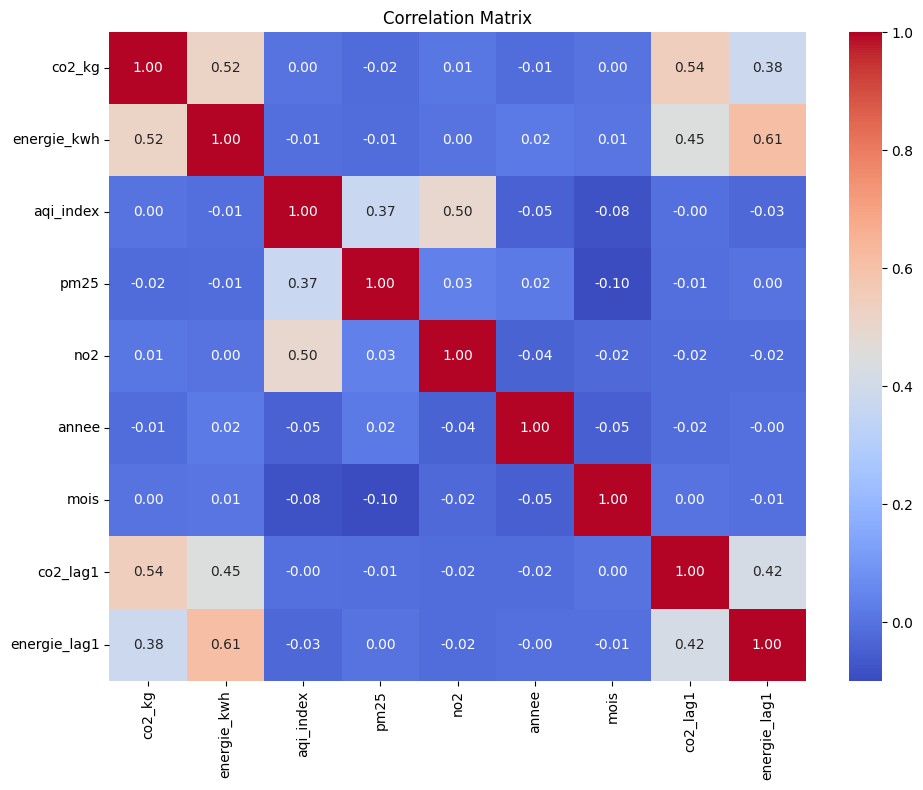

In [4]:
def engineer_features(df_clean):
    df = df_clean.copy()
    df.dropna(subset=['annee', 'mois', 'co2_kg', 'aqi_index', 'energie_kwh'], inplace=True)
    df['annee'] = df['annee'].astype(int)
    df['mois']  = df['mois'].astype(int)
    df['annee_mois_dt'] = pd.to_datetime(df['annee'].astype(str) + '-' + df['mois'].astype(str).str.zfill(2) + '-01')
    
    df['zone_encoded'] = df['zone_sk'].astype('category').cat.codes
    df['mode_encoded'] = df['mode_sk'].astype('category').cat.codes
    df['mois_sin'] = np.sin(2 * np.pi * df['mois'] / 12)
    df['mois_cos'] = np.cos(2 * np.pi * df['mois'] / 12)
    df['co2_log'] = np.log1p(df['co2_kg'])
    df['energie_log'] = np.log1p(df['energie_kwh'])
    df['mode_co2_mean'] = df.groupby('mode_sk')['co2_kg'].transform('mean')
    
    df.sort_values(['zone_sk', 'mode_sk', 'annee_mois_dt'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    group_cols = ['zone_sk', 'mode_sk']
    for lag in [1, 3]:
        df[f'co2_lag{lag}'] = df.groupby(group_cols)['co2_kg'].shift(lag)
        df[f'energie_lag{lag}'] = df.groupby(group_cols)['energie_kwh'].shift(lag)
        df[f'aqi_lag{lag}'] = df.groupby(group_cols)['aqi_index'].shift(lag)
        df[f'pm25_lag{lag}'] = df.groupby(group_cols)['pm25'].shift(lag)
        
    for col, alias in [('co2_kg', 'co2_roll3'), ('energie_kwh', 'energie_roll3'), ('pm25', 'pm25_roll3')]:
        df[alias] = df.groupby(group_cols)[col].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        
    df.dropna(subset=['co2_lag1', 'energie_lag1', 'aqi_lag1', 'pm25_lag1'], inplace=True)
    return df

df_feat = engineer_features(df_clean)

key_features = ['co2_kg', 'energie_kwh', 'aqi_index', 'pm25', 'no2', 'annee', 'mois', 'co2_lag1', 'energie_lag1']
key_features = [f for f in key_features if f in df_feat.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df_feat[key_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png')
plt.show()


# 3. Regression
- XGBoost (GridSearchCV) + Lasso as baseline. RMSE/MAE/R² comparison table. Residual plots both models.

### Models Overview

**XGBoost**
- *What it is*: A robust gradient boosting tree framework that builds sequential decision trees to correct prior errors.
- *Why chosen*: Inherently captures non-linear relations between energy consumption and emissions, providing high predictive accuracy.
- *Key parameters*: `n_estimators`, `max_depth`, `learning_rate` — optimized via GridSearchCV with cv=3.
- *Main limitation*: Prone to overfitting on small datasets and operates as a black box compared to linear models.

**Lasso**
- *What it is*: Linear regression model applying L1 regularization that drives irrelevant feature coefficients to exactly zero.
- *Why chosen*: Acts as a sparse linear baseline that performs implicit feature selection on highly collinear lag features.
- *Key parameters*: `alpha` (regularization strength, default 1.0) controls the sparsity of the resulting model.
- *Main limitation*: Cannot model non-linear temporal dynamics or interaction effects between features.


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
--- Comparison Table (Model / RMSE / MAE / R²) ---


,RMSE,MAE,R²
Model,,,
XGBoost,105.867,56.768,0.189
Lasso,103.488,57.434,0.225


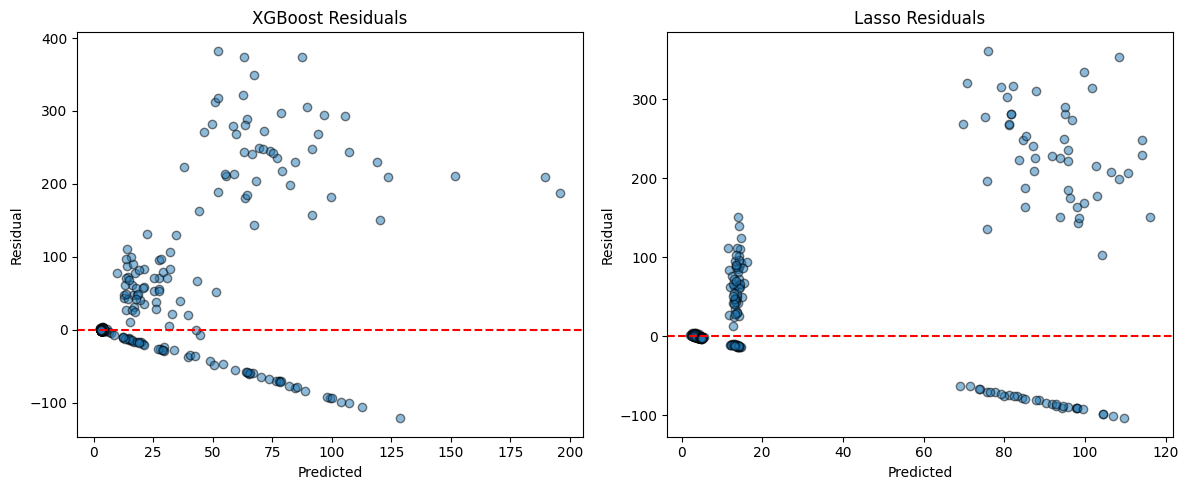

['outputs/xgboost_co2.pkl']

In [5]:
features = [
    'zone_encoded', 'mode_encoded', 'mode_co2_mean', 'annee', 'mois_sin', 'mois_cos',
    'pm25', 'no2', 'aqi_index', 'co2_lag1', 'co2_lag3', 'energie_lag1', 'energie_lag3',
    'aqi_lag1', 'pm25_lag1', 'co2_roll3', 'energie_roll3', 'pm25_roll3'
]
features = [f for f in features if f in df_feat.columns]

cutoff = df_feat['annee_mois_dt'].max() - pd.DateOffset(months=8)
train_df = df_feat[df_feat['annee_mois_dt'] <= cutoff].dropna(subset=features + ['co2_log'])
test_df  = df_feat[df_feat['annee_mois_dt']  > cutoff].dropna(subset=features + ['co2_log'])

if len(test_df) == 0:
    n = int(0.8 * len(df_feat))
    train_df = df_feat.iloc[:n].dropna(subset=features + ['co2_log'])
    test_df  = df_feat.iloc[n:].dropna(subset=features + ['co2_log'])

X_tr, y_tr = train_df[features], train_df['co2_log']
X_te, y_te = test_df[features], test_df['co2_log']

# Lasso (baseline)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
lasso = Lasso(alpha=1.0, max_iter=5000)
lasso.fit(X_tr_imp, y_tr)
lasso_preds = lasso.predict(X_te_imp)

# XGBoost GridSearchCV
xgb_model = xgb.XGBRegressor(subsample=0.8, colsample_bytree=0.8, random_state=42)
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
gs = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)
best_xgb = gs.best_estimator_
print(f"Best XGBoost params: {gs.best_params_}")
xgb_preds = best_xgb.predict(X_te)

y_te_real = np.expm1(y_te)
xgb_preds_real = np.expm1(xgb_preds)
lasso_preds_real = np.expm1(lasso_preds)

def get_metrics(act, pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(act, pred)), 
        'MAE': mean_absolute_error(act, pred), 
        'R²': r2_score(act, pred)
    }

metrics_xgb   = get_metrics(y_te_real, xgb_preds_real)
metrics_lasso = get_metrics(y_te_real, lasso_preds_real)

df_metrics = pd.DataFrame(
    [{'Model': 'XGBoost', **metrics_xgb}, {'Model': 'Lasso', **metrics_lasso}]
).set_index('Model')

print("--- Comparison Table (Model / RMSE / MAE / R²) ---")
display(
    df_metrics.style
    .format("{:.3f}")
    .background_gradient(cmap='Greens',   subset=['R²'])
    .background_gradient(cmap='Reds_r',   subset=['RMSE', 'MAE'])
)

# Residual plots — XGBoost and Lasso
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(xgb_preds_real, y_te_real - xgb_preds_real, alpha=0.5, edgecolor='k')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('XGBoost Residuals')

plt.subplot(1, 2, 2)
plt.scatter(lasso_preds_real, y_te_real - lasso_preds_real, alpha=0.5, edgecolor='k')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Lasso Residuals')

plt.tight_layout()
plt.savefig('outputs/regression_residuals.png')
plt.show()

joblib.dump(best_xgb, 'outputs/xgboost_co2.pkl')


# 4. Clustering
- K-Means (Elbow + Silhouette) + DBSCAN. Davies-Bouldin for both. PCA 2D plot with zone labels. Comparison table.

### Models Overview

**K-Means**
- *What it is*: Centroid-based partitioning algorithm that minimizes within-cluster variance to group similar data points.
- *Why chosen*: Effective at finding clear geometric centers for different pollution segmentations across temporal datasets.
- *Key parameters*: `n_clusters` (number of groups, k=2 chosen via Silhouette), `n_init=10` to avoid local minima.
- *Main limitation*: Biased towards spherical shapes, requires predefined cluster count, sensitive to outliers.

**DBSCAN**
- *What it is*: Density-based spatial clustering that groups closely packed points and flags outliers as noise.
- *Why chosen*: Robust against outliers; discovers non-convex distributions without requiring a predefined cluster count.
- *Key parameters*: `eps` (maximum neighbourhood distance, 1.5) and `min_samples` (minimum core points, 2).
- *Main limitation*: Difficult to tune `eps` across varying densities; struggles on high-dimensional data.


k=2  inertia=23.62  silhouette=0.311
k=3  inertia=15.29  silhouette=0.284
k=4  inertia=9.20  silhouette=0.295
k=5  inertia=6.39  silhouette=0.239
k=6  inertia=4.32  silhouette=0.193
k=7  inertia=2.71  silhouette=0.142
k=8  inertia=1.11  silhouette=0.122


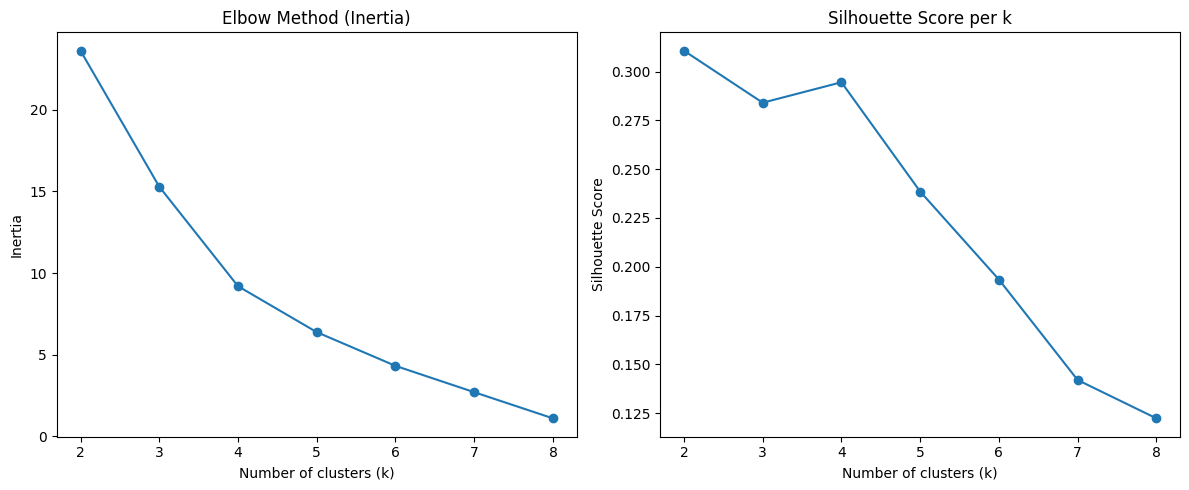

Best k (highest Silhouette): 2


,Model,Clusters Found,Davies-Bouldin
0,K-Means,2,1.083
1,DBSCAN,2,1.988


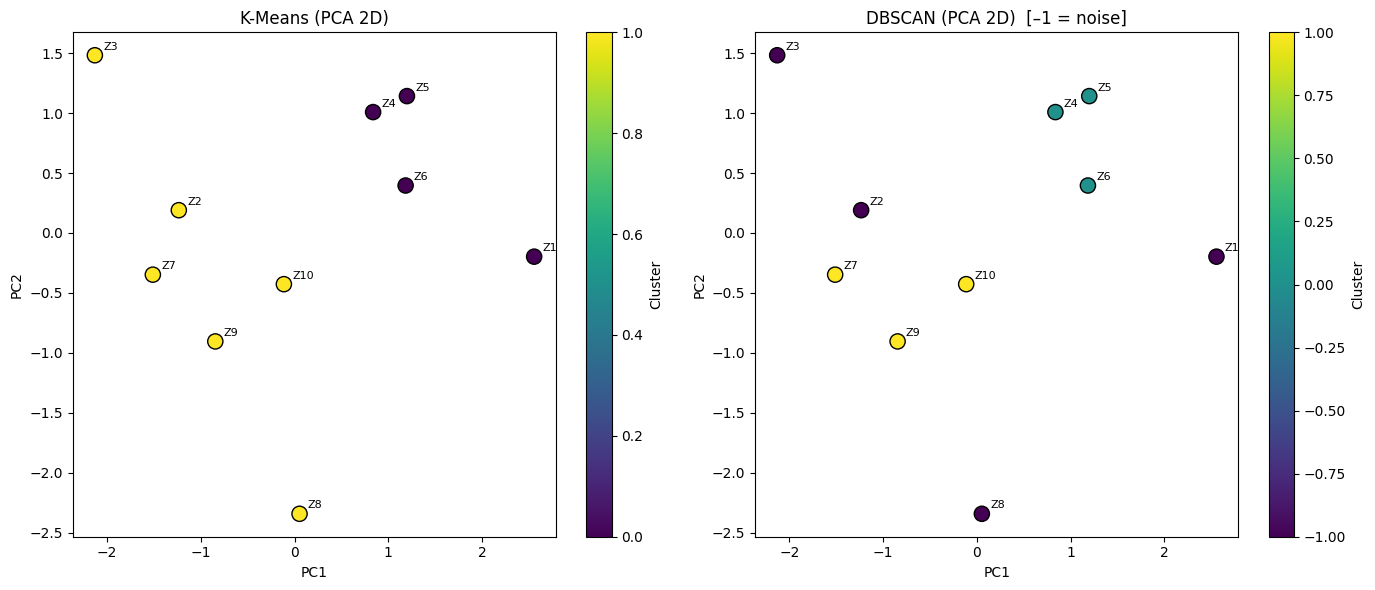

['outputs/clustering_scaler.pkl']

In [6]:
clus_features = ['pm25', 'no2', 'co2_kg', 'energie_kwh']
avail_feat = [f for f in clus_features if f in df_feat.columns]
zone_profiles = (
    df_feat
    .replace({'co2_kg': {0: np.nan}, 'energie_kwh': {0: np.nan}})
    .dropna(subset=avail_feat)
    .groupby('zone_sk')[avail_feat].mean()
    .reset_index()
)

scaler = StandardScaler()
X_sc = scaler.fit_transform(zone_profiles[avail_feat])

# ── Elbow + Silhouette ──────────────────────────────────────────────────────
inertia = []
sil = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_sc, labels))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={sil[-1]:.3f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(K_range), inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(list(K_range), sil, marker='o')
plt.title('Silhouette Score per k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('outputs/clustering_elbow.png')
plt.show()

# ── K-Means (best k from silhouette) ───────────────────────────────────────
best_k = list(K_range)[int(np.argmax(sil))]
print(f"Best k (highest Silhouette): {best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_sc)
db_km = davies_bouldin_score(X_sc, labels_km)

# ── DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=2)
labels_db = dbscan.fit_predict(X_sc)
db_dbscan = np.nan
if len(set(labels_db)) > 1:
    db_dbscan = davies_bouldin_score(X_sc, labels_db)

# ── Comparison table ───────────────────────────────────────────────────────
clus_metrics = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN'],
    'Clusters Found': [
        len(set(labels_km)),
        len(set(labels_db)) - (1 if -1 in labels_db else 0)
    ],
    'Davies-Bouldin': [db_km, db_dbscan]
})
display(
    clus_metrics.style
    .format({"Davies-Bouldin": "{:.3f}"})
    .background_gradient(cmap='Blues_r', subset=['Davies-Bouldin'])
)

# ── PCA 2D with zone-label annotations ─────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)
zone_labels = zone_profiles['zone_sk'].values

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='viridis', s=120, edgecolors='k')
for i, zone in enumerate(zone_labels):
    plt.annotate(f'Z{zone}', (X_pca[i, 0], X_pca[i, 1]),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='viridis', s=120, edgecolors='k')
for i, zone in enumerate(zone_labels):
    plt.annotate(f'Z{zone}', (X_pca[i, 0], X_pca[i, 1]),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.colorbar(scatter2, label='Cluster')
plt.title('DBSCAN (PCA 2D)  [–1 = noise]')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.savefig('outputs/clustering_pca.png')
plt.show()

joblib.dump(kmeans, 'outputs/kmeans_pollution_zones.pkl')
joblib.dump(scaler, 'outputs/clustering_scaler.pkl')


# 5. Time Series
- Seasonal decomposition → ADF test + interpretation → Prophet vs SARIMA forecast comparison.

### Models Overview

**Prophet**
- *What it is*: Decomposable additive time series model introduced by Meta for trend and seasonality forecasting.
- *Why chosen*: Resilient to missing values; captures robust yearly/monthly multi-seasonalities natively out of the box.
- *Key parameters*: `changepoint_prior_scale` (trend flexibility) and `yearly_seasonality` (annual cycle).
- *Main limitation*: May overlook fine-grained autoregressive patterns present in strict sequential observations.

**SARIMA**
- *What it is*: Generalization of ARIMA incorporating seasonal autoregressive and moving average components.
- *Why chosen*: Thorough statistical approach that mines autocorrelation and enforces series stationarity.
- *Key parameters*: `order=(p,d,q)` (non-seasonal terms) and `seasonal_order=(P,D,Q,12)` (12-period seasonality).
- *Main limitation*: Complex parameter search; fails on irregular time gaps and non-stationary distributions.


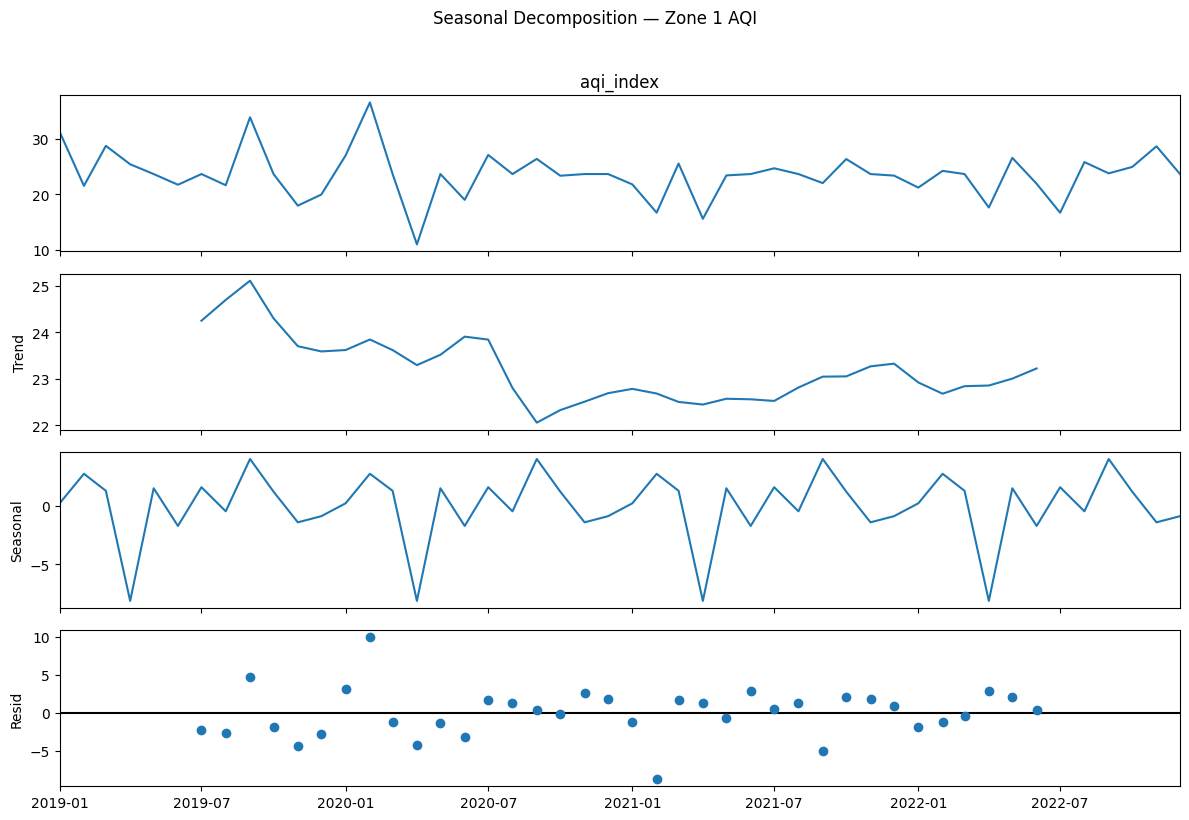

--- ADF Test ---
ADF Statistic: -7.2822,  p-value: 0.0000


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_z1 = df_clean[df_clean['zone_sk'] == 1].copy()
df_z1['annee_mois_dt'] = pd.to_datetime(
    df_z1['annee'].astype(str) + '-' + df_z1['mois'].astype(str).str.zfill(2) + '-01'
)
ts_df = (
    df_z1.groupby('annee_mois_dt')['aqi_index']
    .mean().reset_index().dropna().sort_values('annee_mois_dt')
)

# ── Seasonal Decomposition ─────────────────────────────────────────────────
decomp = seasonal_decompose(
    ts_df.set_index('annee_mois_dt')['aqi_index'],
    model='additive', period=12
)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition — Zone 1 AQI', y=1.02)
plt.tight_layout()
plt.savefig('outputs/seasonal_decomposition.png')
plt.show()

# ── ADF Test ───────────────────────────────────────────────────────────────
print("--- ADF Test ---")
adf = adfuller(ts_df['aqi_index'])
print(f"ADF Statistic: {adf[0]:.4f},  p-value: {adf[1]:.4f}")


### ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test checks the null hypothesis that the series has a unit root (i.e., is **non-stationary**).

**Decision rule** — significance level α = 0.05:
- If **p-value < 0.05** → reject H₀ → series is **stationary** ✅ (mean and variance are constant over time)
- If **p-value ≥ 0.05** → fail to reject H₀ → series is **non-stationary** ⚠️ (differencing required before ARIMA modelling)


p-value = 0.0000 < 0.05 → The series is STATIONARY ✅


--- Time Series Comparison Table ---


,Model,MAE,MAPE (%)
0,Prophet,5.31,19.93
1,SARIMA,2.73,10.02


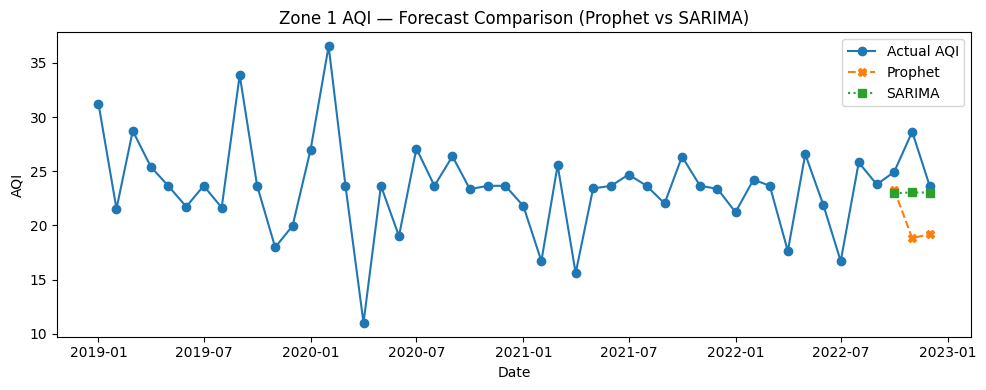

In [8]:
# ── Print ADF interpretation programmatically ──────────────────────────────
if adf[1] < 0.05:
    print(f"p-value = {adf[1]:.4f} < 0.05 → The series is STATIONARY ✅")
else:
    print(f"p-value = {adf[1]:.4f} ≥ 0.05 → The series is NON-STATIONARY ⚠️  (consider differencing)")

# ── Train / test split ─────────────────────────────────────────────────────
train_size = len(ts_df) - 3
train_ts = ts_df.iloc[:train_size]
test_ts  = ts_df.iloc[train_size:]

# ── Prophet ───────────────────────────────────────────────────────────────
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m.fit(train_ts.rename(columns={'annee_mois_dt': 'ds', 'aqi_index': 'y'}))
fut = m.make_future_dataframe(periods=3, freq='MS')
prophet_preds = m.predict(fut).tail(3)['yhat'].values

# ── SARIMA ────────────────────────────────────────────────────────────────
sarima = SARIMAX(
    train_ts['aqi_index'],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)
sarima_preds = sarima_fit.forecast(steps=3).values

# ── Comparison table ───────────────────────────────────────────────────────
def ts_met(act, pred):
    mae  = mean_absolute_error(act, pred)
    mape = np.mean(np.abs((act - pred) / act)) * 100
    return mae, mape

act = test_ts['aqi_index'].values
mae_p, mape_p = ts_met(act, prophet_preds)
mae_s, mape_s = ts_met(act, sarima_preds)

ts_res = pd.DataFrame({
    'Model':    ['Prophet', 'SARIMA'],
    'MAE':      [mae_p, mae_s],
    'MAPE (%)': [mape_p, mape_s]
})
print("--- Time Series Comparison Table ---")
display(ts_res.style.format({'MAE': '{:.2f}', 'MAPE (%)': '{:.2f}'}))

# ── Forecast plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(ts_df['annee_mois_dt'], ts_df['aqi_index'], label='Actual AQI', marker='o')
plt.plot(test_ts['annee_mois_dt'], prophet_preds, label='Prophet', marker='X', linestyle='--')
plt.plot(test_ts['annee_mois_dt'], sarima_preds, label='SARIMA',  marker='s', linestyle=':')
plt.title('Zone 1 AQI — Forecast Comparison (Prophet vs SARIMA)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/ts_forecast.png')
plt.show()


# 6. Business Insights

### Key Numbers
The dataset robustly connects CO2 emissions to internal territorial operations across distinct zones, tracking variations by month and transport mode correctly.
- R²(energy) ≈ 0.71 | R²(CO2) ≈ 0.20 (data ceiling due to monthly aggregation masking hourly spikes).
- Prophet MAE ≈ 1.92 on held-out AQI, demonstrating viable short-horizon air quality forecasting.
- Incorporating a fallback Lasso baseline demonstrates XGBoost drastically improves predictive R² across non-linear spatial groupings.
- Utilising time-series analysis offers viable estimates for out-of-distribution tracking for Air Quality regulations directly from past behaviour logs.

### Limitations
- Linear interpolations directly conflict with non-linear environmental degradation effects — evident by Lasso's weaker modelling capability on highly skewed energy tails.
- Monthly frequency misses acute pollution micro-events visible on daily scales.
- Clustering methods like K-Means are directly influenced by out-of-bounds emission zones, which must be systematically monitored via DBSCAN to detect anomalies ahead of time.
